# AirBnB Product Project

* By: Nhi Bui

# Location Analysis for Neighbourhood Performance and Growth Opportunities

## Question 3
Which neighbourhoods show the highest listing quality (review ratings) and booking activity (reviews per month) to identify where Airbnb should focus growth efforts?

## My proposed approach
1. Analyze review ratings and review activity across NYC boroughs and neighbourhoods
2. Identify high-performing and underperforming areas
3. Provide data-driven recommendations on where to concentrate host acquisition and marketing

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

df = pd.read_csv('../data/Airbnb_Open_Data_Cleaned.csv')
print(df.shape)

(63718, 21)


In [8]:
#Recode the neighbourhood group variable from "brookln" to "Brooklyn"
df['neighbourhood group'] = df['neighbourhood group'].replace('brookln', 'Brooklyn')

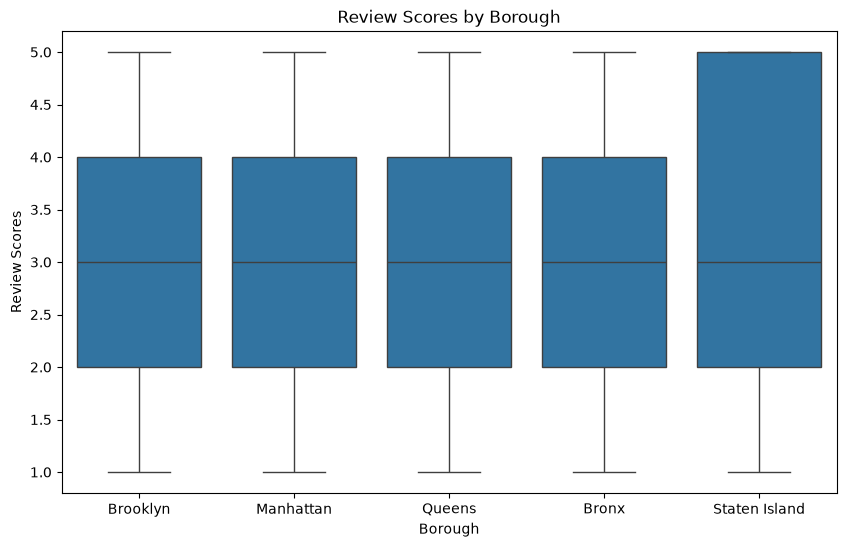

In [9]:
#Compare review ratings for different boroughs
plt.figure(figsize=(10, 6))
sns.boxplot(x='neighbourhood group', y='review rate number', data=df)
plt.title('Review Scores by Borough')
plt.xlabel('Borough')
plt.ylabel('Review Scores')
plt.show()

**Review Scores by Borough (Boxplot):**

* All boroughs show similar median review ratings (~3.0), with Staten Island displaying the widest variance - indicating inconsistent listing quality
* Brooklyn, Manhattan, Queens, and Bronx show identical distributions, suggesting that borough alone does not strongly differentiate review quality.


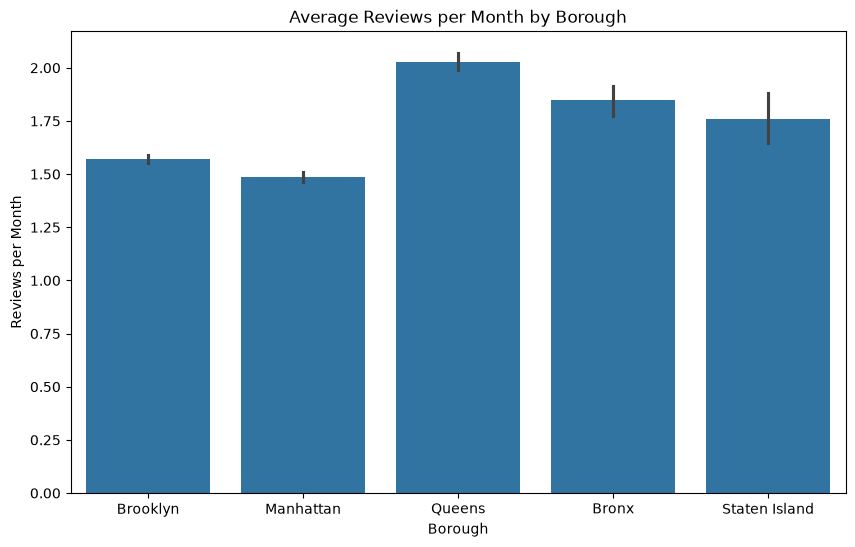

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='neighbourhood group', y='reviews per month')
plt.title('Average Reviews per Month by Borough')
plt.xlabel('Borough')
plt.ylabel('Reviews per Month')
plt.show()

**Average Reviews per Month by Borough (Barplot):**

* Queens leads in average monthly review activity (~2.0), followed by Bronx (~1.85) and Staten Island (~1.75)

* Surprisingly, despite having the most listings, Manhattan ranks lowest in average reviews per month (~1.49)

=> This suggests that outer boroughs may have stronger per-listing engagement, which is possibly due to less competition and more unique guest experiences.

In [11]:
#Summary table combining average review ratings, average reviews per month, and listing counts by borough
df.groupby('neighbourhood group').agg(
    avg_rating=('review rate number', 'mean'),
    avg_reviews_per_month=('reviews per month', 'mean'),
    listing_count=('id', 'count')
).sort_values('avg_reviews_per_month', ascending=False)

,avg_rating,avg_reviews_per_month,listing_count
neighbourhood group,,,
Queens,3.339369,2.028555,9388
Bronx,3.355295,1.848795,2049
Staten Island,3.392622,1.759236,759
Brooklyn,3.269292,1.569812,25775
Manhattan,3.285859,1.486506,25747


**Growth Opportunity Analysis:**
To identify where Airbnb should focus growth efforts, we look for boroughs with the best combination of high quality (ratings), high engagement (reviews per month), and low supply (room to grow).

* Staten Island: highest rating (3.39) and lowest supply (759)
=> Its small sample size and high variance make it an unreliable investment target
* Manhattan: most listings (25,747) with the lowest activity and below-average ratings
=> A saturated market with diminishing returns
* Queen: leads in activity but already has moderate supply (9,388)
* Bron: stands out as the strongest growth candidate with the highest rating (3.36), second-highest activity (1.85/month), and only 2,049 listings, which a large enough sample to trust the data, but small enough supply to indicate significant untapped demand

**=> Decision: I propose to focus deeper analysis on the Bronx to identify  high-potential neighbourhoods for targeted host acquisition and marketing.**

In [13]:
#Drill down to the top neighbourhoods within the Bronx
bronx = df[df['neighbourhood group'] == 'Bronx']
bronx.groupby('neighbourhood').agg(
    avg_rating=('review rate number', 'mean'),
    avg_reviews_per_month=('reviews per month', 'mean'),
    listing_count=('id', 'count')
).sort_values('avg_reviews_per_month', ascending=False).head(10)

,avg_rating,avg_reviews_per_month,listing_count
neighbourhood,,,
Castle Hill,2.750000,3.318750,8
Schuylerville,3.488889,2.597556,45
East Morrisania,3.277778,2.518333,18
Van Nest,3.363636,2.489091,22
Mott Haven,3.434426,2.447541,122
Throgs Neck,3.442308,2.441923,52
Belmont,3.548387,2.401613,31
Woodlawn,3.208333,2.399167,24
Mount Eden,4.200000,2.343000,10


## Location Analysis Conclusion  

**Top Growth Neighbourhoods in the Bronx:**
1. **Mott Haven** with 122 listings, 3.43 avg rating, 2.45 reviews/month as it has the most reliable data and strong performance 
2. **Schuylerville** with 45 listings, 3.49 avg rating, 2.60 reviews/month, as it has the highest activity and a strong average rating
3. **Belmont** with 31 listings, 3.55 avg rating, 2.40 reviews/month, as it has the highest average rating and a strong number of reviews/month

**Product Recommendations:**
1. **Targeted host acquisition campaigns** 
Mott Haven, Schuylerville, and Belmont demonstrate guest demand (high reviews/month) with limited supply (below 125 listings/area)
=> Hosts who list here are likely to succeed
2. **New host incentives** 
We sugges implemenenting reduced service fees or professional photography for first-time hosts in these areas to accelerate supply growth
3. **Neighbourhood spotlight features** 
In the Airbnb ap, we can drive guest awareness of these emerging areas, positioning them as authentic NYC alternatives to saturated Manhattan listings in spotlight features of apps
4. **Performance monitoring dashboard** 
We can install dashboard t track whether increased host supply maintains or dilutes the current quality and engagement levels in these neighbourhoods for real-time adjustments